# Tutorial 27: When the Average Hides the Action - Distributional DiD with Changes-in-Changes

A loyalty program was rolled out to a lower-spend customer segment. Finance ran the
standard difference-in-differences on monthly spend and got a flat zero - the program
looks dead, and leadership is ready to kill it. This tutorial shows how
**Changes-in-Changes (CiC)** - the distributional DiD estimator of Athey & Imbens
(2006) - reveals that the program in fact worked exactly where it was aimed: it moved
the *bottom half* of the spend distribution, which the mean cannot see under this
much top-end variance.

**What you'll learn**

1. When to reach for CiC instead of (or alongside) mean DiD and the staggered estimators.
2. How to read a quantile-treatment-effect (QTE) profile, and how to make *joint*
   "which quantiles moved" claims with sup-t uniform bands.
3. What the interior point-identification range guardrail does when support is short.
4. CiC's headline robustness property: its distributional answer does not depend on
   whether you analyze levels or logs - and why that is not true for mean DiD or for
   the quantile-DiD (QDiD) comparison estimator.
5. How to adjust for covariate-composition differences with the quantile-regression
   covariate branch (`covariates=`), and what the conditional support diagnostic guards.
6. Where to go next with `practitioner_next_steps()`.


## 1. When is CiC the right tool?

The decision comes down to the *design* and the *question*:

- **Two groups, two periods (2x2), and a distributional question** - "who moved, not
  just how much on average?" - use **ChangesInChanges**. It estimates the treated
  group's full counterfactual outcome distribution, so you get an ATT *and* quantile
  treatment effects on one bootstrap.
- **Mean-only question, trustworthy parallel trends on your chosen scale** - plain
  `DifferenceInDifferences` is simpler and faster.
- **Staggered adoption across many periods** - CiC does not apply (it is 2x2 only);
  use `CallawaySantAnna` or another heterogeneity-robust estimator for mean effects.
- **QDiD** is the quantile-by-quantile DiD comparison estimator. Athey & Imbens (2006,
  p. 447) recommend CiC over it - Section 6 makes their reason concrete on our data.

Our setting is a genuine 2x2 with **repeated cross-sections**: a fresh sample of
customers is drawn each period (typical for transaction panels). CiC also supports
true panels - `panel=True` changes only the bootstrap resampling scheme (unit-block
instead of pooled rows), not the point estimator.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from diff_diff import ChangesInChanges, DifferenceInDifferences, QDiD, practitioner_next_steps


## 2. The data

We simulate the program so that the truth is known by construction - every claim
below can be checked against it. Three ingredients, each realistic on its own:

- **Heavy-tailed spend.** Customer spend is lognormal-ish: median about \$30, a long
  right tail past \$200. The tail is what makes the *mean* a noisy summary.
- **A nonlinear market trend.** Between periods the whole market moves by a smooth
  transformation with `log y_post = ALPHA + GAMMA * log y_pre` and `GAMMA = 1.06`:
  premium spend grows faster than budget spend. Dollar trends are therefore *not*
  parallel across differently-composed groups - and neither are log trends.
- **A targeted program.** The treated group is a lower-spend loyalty segment, and the
  program lift fades smoothly - a logistic in spend rank - from about +65% for
  near-lapsed customers to effectively zero across the segment's upper half. The
  **true mean effect on the treated is \$3.01**.

The seed is locked so every number in the prose is reproducible; a companion drift
test re-derives them against the installed library.


In [2]:
SEED = 27
N_CELL = 901  # 17*53 - coprime to 20 (quantile grid) and 100 (QR tau grid)

MU_LOG, SIGMA_LOG = 3.4, 0.75  # log-spend location/scale: median spend ~ $30
GAMMA, ALPHA = 1.06, -0.17  # market trend: log y_post = ALPHA + GAMMA * log y_pre
U_LO, U_HI = 0.05, 0.90  # loyalty segment spans the interior of the spend distribution
BETA_A, BETA_B = 1.2, 2.2  # segment tilt toward lower spenders
LIFT_MAX, LIFT_MID, LIFT_SCALE = 0.65, 0.22, 0.07  # program lift, strongest for near-lapsed


def h_pre(u):
    return np.exp(MU_LOG + SIGMA_LOG * stats.norm.ppf(u))


def h_post(u):
    return np.exp(ALPHA + GAMMA * (MU_LOG + SIGMA_LOG * stats.norm.ppf(u)))


def lift(u):
    return LIFT_MAX / (1.0 + np.exp((u - LIFT_MID) / LIFT_SCALE))


def make_spend_data(seed=SEED, n=N_CELL):
    rng = np.random.default_rng(seed)
    u00 = rng.uniform(0.0005, 0.9995, n)
    u01 = rng.uniform(0.0005, 0.9995, n)
    u10 = U_LO + (U_HI - U_LO) * rng.beta(BETA_A, BETA_B, n)
    u11 = U_LO + (U_HI - U_LO) * rng.beta(BETA_A, BETA_B, n)
    frames = []
    for g, t, y in (
        (0, 0, h_pre(u00)),
        (0, 1, h_post(u01)),
        (1, 0, h_pre(u10)),
        (1, 1, h_post(u11) * (1.0 + lift(u11))),
    ):
        frames.append(pd.DataFrame({"treated": g, "post": t, "spend": y}))
    return pd.concat(frames, ignore_index=True)


df = make_spend_data()
y00 = df.query("treated == 0 and post == 0")["spend"].to_numpy()
y10 = df.query("treated == 1 and post == 0")["spend"].to_numpy()
y11 = df.query("treated == 1 and post == 1")["spend"].to_numpy()

print(f"{len(df)} rows ({N_CELL} per group x period cell)")
print(f"control pre-period spend:  median ${np.median(y00):.2f}, mean ${y00.mean():.2f}")
print(f"treated pre-period spend:  median ${np.median(y10):.2f}  (lower-spend segment)")


3604 rows (901 per group x period cell)
control pre-period spend:  median $31.03, mean $39.79
treated pre-period spend:  median $20.86  (lower-spend segment)


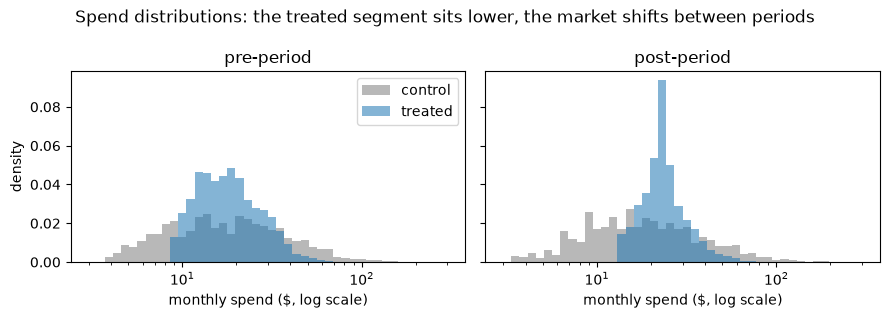

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
bins = np.geomspace(3, 300, 45)
for ax, period, label in ((axes[0], 0, "pre-period"), (axes[1], 1, "post-period")):
    for g, color, name in ((0, "tab:gray", "control"), (1, "tab:blue", "treated")):
        vals = df.query(f"treated == {g} and post == {period}")["spend"]
        ax.hist(vals, bins=bins, density=True, alpha=0.55, color=color, label=name)
    ax.set_xscale("log")
    ax.set_xlabel("monthly spend ($, log scale)")
    ax.set_title(label)
axes[0].set_ylabel("density")
axes[0].legend()
fig.suptitle("Spend distributions: the treated segment sits lower, the market shifts between periods")
fig.tight_layout()
plt.show()


## 3. The mean answer

Standard practice first: difference-in-differences on mean spend, with robust
standard errors.


In [4]:
did = DifferenceInDifferences().fit(df, outcome="spend", treatment="treated", time="post")
print(did.summary())


             Difference-in-Differences Estimation Results             

Observations:                   3604
Treated:                        1802
Control:                        1802
R-squared:                    0.0939
Variance:                            HC1 heteroskedasticity-robust

----------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
----------------------------------------------------------------------
ATT                   0.2178       1.7351      0.126     0.9001      
----------------------------------------------------------------------

95% Confidence Interval: [-3.1841, 3.6197]
CV (SE/abs(ATT)):             7.9670

Signif. codes: '***' 0.001, '**' 0.01, '*' 0.05, '.' 0.1


The mean verdict: **ATT = \$0.22, p = 0.90**, confidence interval [-\$3.18, \$3.62].
By this reading the program did nothing, and it gets killed.

Two things are wrong with that reading, and only one of them is about power:

1. **Noise**: the long spend tail puts the DiD standard error near \$1.74, so even the
   true \$3.01 mean effect would be hard to detect.
2. **Bias**: the market trend is multiplicative (`GAMMA = 1.06`), so *dollar* trends are
   not parallel between a \$21-median segment and a \$31-median control group. Mean DiD
   with these groups does not target the truth on this scale in the first place - the
   \$0.22 is not an unlucky draw around \$3.01.

CiC was built for exactly this situation: it never assumes additive-in-levels trends.


## 4. Changes-in-Changes: the full picture

CiC (Athey & Imbens 2006) treats the control group's period-to-period change as a
*transformation of the whole distribution* and applies that transformation to the
treated group's pre-period distribution. Formally, the counterfactual outcome
distribution is $F_{10}(F_{00}^{-1}(F_{01}(y)))$ (their Theorem 3.1): "give every
treated customer the outcome move that a control customer at the same rank
experienced." Identification needs a monotone outcome model in a scalar unobservable
and time-invariance of that unobservable within groups - *not* parallel mean trends
(more on that in Section 6).

Inference is bootstrap-only (999 replicates here, seeded). The point estimates match
the R `qte` package exactly; see the methodology registry for the parity details.


In [5]:
cic = ChangesInChanges(n_bootstrap=999, seed=SEED).fit(
    df, outcome="spend", treatment="treated", time="post"
)
print(cic.summary())


                    Changes-in-Changes (Athey & Imbens 2006) Results                    
Observations: 3604    Mode: repeated cross-section
Cells: control pre=901, control post=901, treated pre=901, treated post=901
Inference: bootstrap (999/999 valid replicates), replicate-SD SEs, normal-approximation intervals
Point-identified interior quantile range (eq. 17): (0.0000, 1.0000)
----------------------------------------------------------------------------------------
              Estimate     Std.Err         t     P>|t|  [95% Conf. Int.]
----------------------------------------------------------------------------------------
       ATT      3.0476      1.0628      2.87     0.004  [   0.9646,    5.1306] **

Quantile treatment effects:
----------------------------------------------------------------------------------------
      0.05      4.9087      0.8252      5.95     0.000  [   3.2914,    6.5260] ***
      0.10      5.4037      0.9124      5.92     0.000  [   3.6154,    7.1920] ***
 

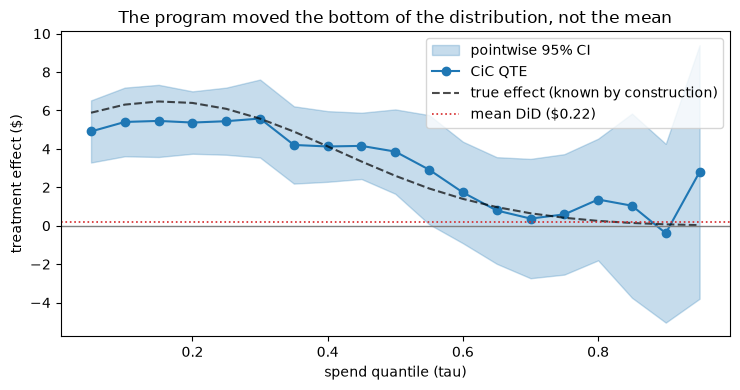

In [6]:
qe = cic.quantile_effects

# The DGP is synthetic, so the true QTE curve is computable by Monte Carlo:
rng_mc = np.random.default_rng(123456)
u_mc = U_LO + (U_HI - U_LO) * rng_mc.beta(BETA_A, BETA_B, 2_000_000)
truth = np.quantile(h_post(u_mc) * (1 + lift(u_mc)), cic.quantiles) - np.quantile(
    h_post(u_mc), cic.quantiles
)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.fill_between(qe["quantile"], qe["conf_low"], qe["conf_high"], alpha=0.25,
                color="tab:blue", label="pointwise 95% CI")
ax.plot(qe["quantile"], qe["qte"], "o-", color="tab:blue", label="CiC QTE")
ax.plot(cic.quantiles, truth, "--", color="black", alpha=0.7,
        label="true effect (known by construction)")
ax.axhline(0, color="gray", lw=1)
ax.axhline(did.att, color="tab:red", lw=1.2, ls=":", label=f"mean DiD (${did.att:.2f})")
ax.set_xlabel("spend quantile (tau)")
ax.set_ylabel("treatment effect ($)")
ax.set_title("The program moved the bottom of the distribution, not the mean")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


The QTE profile tells the real story: **+\$4.91 at the 5th percentile, +\$5.44 at the
25th, +\$3.86 at the median, and nothing distinguishable from zero above the 70th**.
For a \$15-25/month customer, a \$5 lift is a 20-30% change - the program reactivated
near-lapsed customers, exactly its design goal.

Note the headline ATT: **\$3.05 (p = 0.004)**, right on the \$3.01 truth - CiC's mean
is the mean of a *correctly constructed* counterfactual distribution, so it does not
inherit mean DiD's nonparallel-dollar-trend bias. Same data, same 2x2, two very
different answers - and here the distributional one is right by construction.


## 5. Which quantiles moved? Joint claims and the interior range

Reading 19 pointwise confidence intervals off the plot and declaring "significant
below the median" is a multiple-testing mistake - pointwise intervals over-reject
when read jointly. For joint statements use `uniform_bands()`: simultaneous sup-t
bands over the whole grid, computed at the qte package's fixed 95% level (the band
level deliberately does *not* follow `alpha`; that is the parity convention).


sup-t critical value: 3.260
quantiles whose uniform band excludes zero: ['0.05', '0.10', '0.15', '0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50']


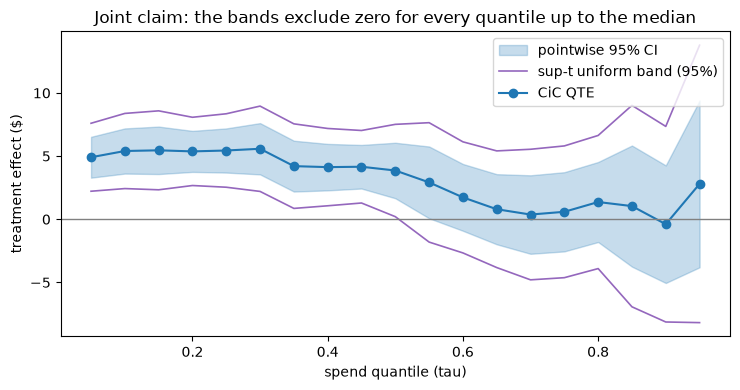

In [7]:
bands = cic.uniform_bands()
excluded = (bands["band_low"] > 0) | (bands["band_high"] < 0)
sig = [f"{t:.2f}" for t, e in zip(cic.quantiles, excluded) if e]
print(f"sup-t critical value: {cic.sup_t_crit:.3f}")
print(f"quantiles whose uniform band excludes zero: {sig}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.fill_between(qe["quantile"], qe["conf_low"], qe["conf_high"], alpha=0.25,
                color="tab:blue", label="pointwise 95% CI")
ax.plot(bands["quantile"], bands["band_low"], "-", color="tab:purple", lw=1.2,
        label="sup-t uniform band (95%)")
ax.plot(bands["quantile"], bands["band_high"], "-", color="tab:purple", lw=1.2)
ax.plot(qe["quantile"], qe["qte"], "o-", color="tab:blue", label="CiC QTE")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("spend quantile (tau)")
ax.set_ylabel("treatment effect ($)")
ax.set_title("Joint claim: the bands exclude zero for every quantile up to the median")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


The joint statement survives: **the uniform bands exclude zero for every grid
quantile from 0.05 through 0.50, and for none above** - so "the program lifted the
bottom half of the spend distribution" holds as a single, simultaneous claim.

Be precise about what the bands say above the median: they are *silent*, not
exonerating. Non-exclusion of zero is absence of evidence, not evidence of absence -
on real data you would report "no detectable effect above the median", never "zero
effect". (Notice the pointwise row at tau = 0.55: nominally significant at p = 0.044.
That is exactly the kind of isolated pointwise blip that evaporates under the joint
bands - chasing it would be the multiple-testing mistake this section is about. Here
we happen to know the truth is ~0 above the median by construction.)

**The interior-range guardrail.** CiC quantile effects are point-identified only
strictly inside an interior range $(q_{lower}, q_{upper})$ - eq. (17) of the paper -
determined by where the treated pre-period distribution sits inside the control
pre-period support. Our sample is support-clean, so the range is the trivial
$(0, 1)$ and every grid quantile is interior. But short support is common in
practice - suppose the control sample had only covered *mid-market* customers.
CiC does not fail silently: watch the warnings this variant raises, and what happens
to the tail inference.


In [8]:
def make_midmarket_variant(seed=SEED, n=N_CELL):
    # Same market, same program - but the control SAMPLE only covers
    # mid-market customers (spend ranks 15%-85%).
    rng = np.random.default_rng(seed + 1)
    u00 = rng.uniform(0.15, 0.85, n)
    u01 = rng.uniform(0.15, 0.85, n)
    u10 = U_LO + (U_HI - U_LO) * rng.beta(BETA_A, BETA_B, n)
    u11 = U_LO + (U_HI - U_LO) * rng.beta(BETA_A, BETA_B, n)
    frames = []
    for g, t, y in (
        (0, 0, h_pre(u00)),
        (0, 1, h_post(u01)),
        (1, 0, h_pre(u10)),
        (1, 1, h_post(u11) * (1.0 + lift(u11))),
    ):
        frames.append(pd.DataFrame({"treated": g, "post": t, "spend": y}))
    return pd.concat(frames, ignore_index=True)


cic_v = ChangesInChanges(n_bootstrap=999, seed=SEED).fit(
    make_midmarket_variant(), outcome="spend", treatment="treated", time="post"
)
print(f"interior range: ({cic_v.q_lower:.4f}, {cic_v.q_upper:.4f})")
print("\nquantiles outside the interior range (point estimates kept, inference NaN):")
print(cic_v.quantile_effects[cic_v.quantile_effects["se"].isna()].to_string(index=False))


interior range: (0.1698, 0.9956)

quantiles outside the interior range (point estimates kept, inference NaN):
 quantile      qte  se  t_stat  p_value  conf_low  conf_high
     0.05 2.726330 NaN     NaN      NaN       NaN        NaN
     0.10 4.696848 NaN     NaN      NaN       NaN        NaN
     0.15 6.264059 NaN     NaN      NaN       NaN        NaN


diff_diff/changes_in_changes.py:981: UserWarning: Treated pre-period outcomes fall outside the control pre-period support (Athey-Imbens Assumption 3.4 violated). The counterfactual distribution is only partially identified (Corollary 3.1): quantile effects are reliable only inside the reported (q_lower, q_upper) interior range, and the ATT involves extrapolation at the support edges.
  _check_support(cells)
diff_diff/changes_in_changes.py:1324: UserWarning: Quantile effects at [0.05, 0.1, 0.15] lie outside the point-identified interior range (0.1698, 0.9956) (Athey-Imbens eq. 17 / Theorem 5.3). Point estimates are reported for qte parity, but their inference fields are set to NaN.
  return _fit_distributional(


Two warnings fired, on purpose and loudly: treated customers fall outside the
control sample's support (Athey-Imbens Assumption 3.4), and the quantiles at
0.05-0.15 lie outside the resulting interior range **(0.17, 0.996)**. Those tail
effects keep their point estimates (matching the R `qte` package) but report NaN
inference - the estimator refuses to hand you confidence intervals for quantiles
where the counterfactual is extrapolated. If you see these warnings on real data,
fix the sampling frame or report the interior range alongside the tails.


## 6. Scale is not a nuisance: levels, logs, and why CiC doesn't care

Every mean-DiD practitioner has faced the question: *levels or logs?* Parallel
trends on one scale generally fails on the other, so the modeling choice changes the
answer. On our data it changes the answer *completely*:


In [9]:
df_log = df.assign(log_spend=np.log(df["spend"]))
did_log = DifferenceInDifferences().fit(
    df_log, outcome="log_spend", treatment="treated", time="post"
)
print(f"DiD on spend ($):    ATT = {did.att:+.2f}   (p = {did.p_value:.3f})  -> 'no effect'")
print(
    f"DiD on log(spend):   ATT = {did_log.att:+.4f}  (p = {did_log.p_value:.4f})"
    f"  -> '+{100 * (np.exp(did_log.att) - 1):.1f}% - big win'"
)


DiD on spend ($):    ATT = +0.22   (p = 0.900)  -> 'no effect'
DiD on log(spend):   ATT = +0.1307  (p = 0.0011)  -> '+14.0% - big win'


Same data: **\$0.22 (p = 0.90)** in dollars, **+14.0% (p = 0.001)** in logs. Neither
scale has parallel trends here (the market trend is `y -> e^ALPHA * y^GAMMA`, which is
additive in *neither* dollars nor logs across differently-composed groups), so
neither number should be trusted - but nothing in the output tells you that. The
scale choice silently *is* the identification assumption.

CiC removes that choice from the table. Its identifying assumptions - a monotone
outcome model and time-invariant unobservables - are statements about *ranks*, so
they are unchanged by any strictly increasing transformation. For unconditional fits
the estimated counterfactual distribution is **equivariant**: fit in dollars or fit
in logs, and you get the same answer mapped through the transformation. Concretely,
the counterfactual quantiles from the levels fit equal `exp()` of the counterfactual
quantiles from the log fit, up to floating-point rounding:


In [10]:
cic_log = ChangesInChanges(n_bootstrap=0).fit(
    df_log, outcome="log_spend", treatment="treated", time="post"
)

# Counterfactual quantiles = treated-post quantiles minus the QTE. CiC's internal
# quantile convention is R type-1 (an order statistic - no interpolation), which
# numpy calls "inverted_cdf". Order statistics commute with monotone transforms,
# and no n*tau lands on an integer (901 is coprime to 20), so the identity is
# exact up to the exp/log round-trip:
grid = cic.quantiles
q11_lvl = np.quantile(y11, grid, method="inverted_cdf")
q11_log = np.quantile(np.log(y11), grid, method="inverted_cdf")
cf_levels_fit = q11_lvl - cic.quantile_effects["qte"].to_numpy()
cf_log_fit = np.exp(q11_log - cic_log.quantile_effects["qte"].to_numpy())

comparison = pd.DataFrame(
    {"tau": grid, "cf_from_levels_fit": cf_levels_fit, "cf_from_log_fit": cf_log_fit}
)
print(comparison.iloc[[2, 9, 14, 18]].to_string(index=False))
max_rel = np.max(np.abs(cf_levels_fit - cf_log_fit) / cf_levels_fit)
print(f"\nmax relative difference across all 19 quantiles: {max_rel:.2e}")


 tau  cf_from_levels_fit  cf_from_log_fit
0.15           13.902084        13.902084
0.50           20.316616        20.316616
0.75           29.905258        29.905258
0.95           45.271539        45.271539

max relative difference across all 19 quantiles: 0.00e+00


The two fits agree to floating-point precision (the only daylight is the `exp`/`log`
round-trip, at most a few units in the last bit - on this machine it is exactly
zero). The levels-vs-logs debate simply does not arise for CiC's distributional
answer. (The scope matters: this exact equivariance holds for *unconditional* fits -
the covariate branch in Section 7 runs linear quantile regressions, which are not
equivariant to nonlinear transforms. And means never commute with transforms, so the
ATT is scale-specific for every estimator, CiC included.)

**QDiD does not have this property**, and that is the substance of Athey & Imbens's
recommendation (p. 447): QDiD imposes the additive quantile-DiD model on whatever
scale you happen to fit, so its answer *shifts* with the scale:


In [11]:
qdid = QDiD(n_bootstrap=0).fit(df, outcome="spend", treatment="treated", time="post")
qdid_log = QDiD(n_bootstrap=0).fit(
    df_log, outcome="log_spend", treatment="treated", time="post"
)

# Back-transform the log-scale QDiD profile to dollars (QDiD's treated-post
# quantiles are R type-7, numpy's default "linear" interpolation):
q11_t7_log = np.quantile(np.log(y11), grid, method="linear")
qdid_backmapped = np.exp(q11_t7_log) - np.exp(q11_t7_log - qdid_log.quantile_effects["qte"].to_numpy())
qdid_gap = qdid.quantile_effects["qte"].to_numpy() - qdid_backmapped

table = pd.DataFrame(
    {
        "tau": grid,
        "QDiD_levels": qdid.quantile_effects["qte"].to_numpy(),
        "QDiD_logs_backmapped": qdid_backmapped,
        "gap": qdid_gap,
        "CiC_levels": cic.quantile_effects["qte"].to_numpy(),
    }
)
print(table.iloc[[4, 9, 14, 17]].round(2).to_string(index=False))
print(f"\nQDiD levels-vs-logs gap: median |gap| = {np.median(np.abs(qdid_gap)):.2f}, "
      f"max |gap| = {np.max(np.abs(qdid_gap)):.2f} (at tau = {grid[np.argmax(np.abs(qdid_gap))]:.2f})")


 tau  QDiD_levels  QDiD_logs_backmapped   gap  CiC_levels
0.25         5.61                  5.61 -0.00        5.44
0.50         2.59                  2.83 -0.24        3.86
0.75        -3.77                 -1.67 -2.10        0.59
0.90        -8.48                 -2.84 -5.65       -0.39

QDiD levels-vs-logs gap: median |gap| = 0.24, max |gap| = 5.65 (at tau = 0.90)


The gap grows toward the top of the distribution - **\$0.24 at the median, \$2.10 at
the 75th percentile, \$5.65 at the 90th** - and worse, QDiD-in-levels reports a
*loss* of \$8.48 at the 90th percentile where the truth (and CiC) say zero: its
additive dollar model extrapolates the control group's premium-segment dollar growth
onto a treated segment that has no premium customers. Fit QDiD on logs instead and
that loss shrinks by two-thirds. An estimator whose story changes with the analyst's
scale choice is a fragile primary; use QDiD as a cross-check beside CiC, not instead
of it. (When QDiD's implied counterfactual quantile curve is non-monotone - another
symptom of the same model failure - the fit warns; on this data it stays monotone on
both scales.)


## 7. When the mix differs: covariates

CiC's time-invariance assumption can fail *observably*: if the treated and control
groups differ in composition on a variable that also drives the period-to-period
trend, the unconditional counterfactual attributes the wrong trend to the treated
group. The fix is to condition: `covariates=` runs the comparison *within* covariate
values (per-cell linear quantile regressions on a 99-tau grid - an exact port of the
R `qte` package's `xformla` branch, including its conditional-rank imputation).

Here is a second program where that matters. The outcome is an engagement index; the
treated group skews toward **longer-tenure** customers (`+0.8` years on average), and
this quarter's organic engagement growth is strongly tenure-driven while tenure's
*level* link is weak - latent-index slopes `0.6` (trend) vs `0.15` (level), which the
`x8` index scaling turns into **4.8 vs 1.2 engagement points per tenure-year**. That
trend/level decoupling is what makes the confounding bite. The program's true effect
is **6.0 points**, constant for everyone.


In [12]:
COV_SEED, COV_N = 272, 299  # cell size coprime to 100 (QR tau grid)
COV_EFFECT = 6.0  # true program effect, engagement points
COV_SHIFT, COV_TREND, COV_LEVEL, COV_SCALE = 0.8, 0.6, 0.15, 8.0


def make_engagement_data(seed=COV_SEED, n=COV_N):
    rng = np.random.default_rng(seed)
    frames = []
    for g in (0, 1):
        for t in (0, 1):
            x = rng.uniform(0, 2, n) + COV_SHIFT * g  # tenure (years, centered scale)
            noise = rng.normal(0, 0.4, n)
            y = COV_SCALE * (0.5 + COV_LEVEL * x + COV_TREND * x * t + noise) + COV_EFFECT * g * t
            frames.append(pd.DataFrame({"treated": g, "post": t, "tenure": x, "engagement": y}))
    return pd.concat(frames, ignore_index=True)


eng = make_engagement_data()

cic_unc = ChangesInChanges(n_bootstrap=999, seed=SEED).fit(
    eng, outcome="engagement", treatment="treated", time="post"
)
# The covariate branch refits every per-cell quantile regression inside every
# bootstrap replicate - this cell takes about a minute:
cic_cov = ChangesInChanges(n_bootstrap=99, seed=SEED).fit(
    eng, outcome="engagement", treatment="treated", time="post", covariates=["tenure"]
)

print(f"true effect:        {COV_EFFECT:.1f} points")
print(f"unconditional CiC:  ATT = {cic_unc.att:.2f}  "
      f"CI [{cic_unc.conf_int[0]:.2f}, {cic_unc.conf_int[1]:.2f}]")
print(f"conditional CiC:    ATT = {cic_cov.att:.2f}  "
      f"CI [{cic_cov.conf_int[0]:.2f}, {cic_cov.conf_int[1]:.2f}]   (covariates=['tenure'])")


true effect:        6.0 points
unconditional CiC:  ATT = 9.38  CI [8.32, 10.45]
conditional CiC:    ATT = 6.53  CI [5.35, 7.70]   (covariates=['tenure'])


The unconditional fit reports **9.38 with CI [8.32, 10.45]** - confidently wrong,
because the tenure-driven trend is not a monotone transformation of the *outcome*
(the trend/level decoupling is what breaks the unconditional assumption). Conditioning
on tenure brings the estimate to **6.53 with CI [5.35, 7.70]**, covering the truth.

Practical notes for the covariate branch:

- Covariates must be **numeric** (dummy-encode categoricals first).
- A **conditional support diagnostic** replaces the interior-range guardrail: if more
  than 10% of treated pre-period outcomes fall outside their conditional quantile
  envelope, a warning flags out-of-support extrapolation (Melly & Santangelo 2015,
  Assumption 4). This fit is clean, so no warning fired.
- Bootstrap cost scales with the quantile-regression refits - budget minutes, not
  seconds, at larger sizes (the same cost profile as the R `qte` package).


## 8. What next

Fitted results know their own follow-up work: `practitioner_next_steps()` reads the
estimator type, covariate status, and bootstrap health, and returns the remaining
steps of the Baker, Callaway, Cunningham, Goodman-Bacon & Sant'Anna (2025) workflow,
with runnable snippets that mirror this fit's exact specification.


In [13]:
guidance = practitioner_next_steps(cic)



Practitioner Guidance — ChangesInChanges (CiC)
Baker et al. (2025) 8-Step Workflow

Recommended next steps (9 remaining):

  * [HIGH] Step 1: Define target parameter
    Why: State explicitly what causal effect you are estimating (ATT, ATT(g,t), weighted/unweighted) and what policy question it answers.
    >>> # What is the target parameter? ATT? Weighted or unweighted?

  * [HIGH] Step 2: State identification assumptions (distributional)
    Why: Name the distributional assumptions you are invoking - not a mean parallel-trends variant. CiC (Athey-Imbens 2006, Assumptions 3.1-3.4) requires a monotone outcome model h(U, T) strictly increasing in a scalar unobservable U, time-invariance of U within groups (U independent of T given G), and support inclusion; add no-anticipation and the continuous-outcome scope.
    >>> # Which distributional assumptions? Monotonicity in U? Time-invariance? Support?

  * [HIGH] Step 3: Assess the distributional identifying assumptions (not mean parallel t

### Takeaways

- **When the question is "who moved?", the mean is the wrong summary.** Our program
  produced +\$5 effects across the bottom half of the spend distribution while mean
  DiD read \$0.22 (p = 0.90) - both noisy *and* biased under a nonlinear market trend.
- **CiC gives you the whole distribution for one bootstrap**: ATT (here \$3.05,
  matching the \$3.01 truth), per-quantile effects with pointwise CIs, and sup-t
  uniform bands for joint claims.
- **Guardrails are loud**: short support triggers explicit warnings and NaN inference
  outside the interior range instead of silent extrapolation.
- **Scale-robustness is CiC's differentiator**: levels-vs-logs changes mean DiD's
  verdict from "nothing" to "+14%" and moves QDiD's profile by dollars, while CiC's
  distributional answer is identical either way (unconditional fits).
- **Composition differences are fixable**: `covariates=` turned a confidently-wrong
  9.4 into a truth-covering 6.5 in the tenure example.
- CiC is **2x2 only**: for staggered rollouts use `CallawaySantAnna`; for mean-only
  questions with trustworthy parallel trends, plain DiD remains simpler.

### Not covered here (documented deferrals)

Discrete-outcome bounds (Athey-Imbens Section 4 - the ties warning marks that
boundary), analytical standard errors, the full Melly-Santangelo covariate
estimator, and staggered/multi-period distributional DiD. See `TODO.md` and the
methodology registry for status.

### References

- Athey, S. & Imbens, G. W. (2006). Identification and Inference in Nonlinear
  Difference-in-Differences Models. *Econometrica*, 74(2), 431-497.
- Melly, B. & Santangelo, G. (2015). The Changes-in-Changes Model with Covariates.
  Working paper.
- Baker, A., Callaway, B., Cunningham, S., Goodman-Bacon, A. & Sant'Anna, P. H. C.
  (2025). Difference-in-Differences Designs: A Practitioner's Guide.
- Callaway, B. `qte`: Quantile Treatment Effects (R package) - the parity target for
  this implementation.
